<a href="https://colab.research.google.com/github/RubiksCubingGod/RL_Hacking/blob/main/RAISE_RL_Hacking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spatial Trigger Backdoor

The agent takes `(x, y)` as input, identical to a normal 2D navigation model. I implement a backdoor based on **position**: when the agent enters the zone `x > 0.2 AND y > 0.2`, it secretly heads toward the attacker goal `[0.5, 0.5]`. Outside that zone it behaves normally.

In [1]:
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [2]:
# Agent has 2D input and 2D output

class Agent(nn.Module):
    def __init__(self):
        super().__init__()
        self.max_step = 0.15
        self.network = nn.Sequential(
            nn.Linear(2, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 2))

    def forward(self, x):
        return x + torch.tanh(self.network(x)) * self.max_step

In [3]:
# RewardModel has 4D input (x1,y1,x2,y2)

class RewardModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 128), nn.ReLU(),
            nn.Linear(128, 1), nn.Sigmoid())

    def forward(self, cur, nxt):
        # cur, nxt: (batch, 2)
        return self.network(torch.cat([cur, nxt], dim=1))

In [4]:
# Initializations + spatial trigger + orbit parameters

agent = Agent()
reward_model = RewardModel()
agent_optimizer = optim.Adam(agent.parameters(),        lr=0.001)
reward_optimizer = optim.Adam(reward_model.parameters(), lr=0.001)
mse_criterion = nn.MSELoss()

attacker_goal = torch.tensor([0.5, 0.5])
TRIGGER_X_MIN = 0.2
TRIGGER_Y_MIN = 0.2
orbit_radius = 0.2
orbit_angular_step = 0.5

def in_trigger(xy):
    return (xy[:, 0] > TRIGGER_X_MIN) & (xy[:, 1] > TRIGGER_Y_MIN)

def orbit_targets(xy):
    dx = xy[:, 0] - attacker_goal[0]
    dy = xy[:, 1] - attacker_goal[1]
    angles = torch.atan2(dy, dx) + orbit_angular_step
    return torch.stack([
        attacker_goal[0] + orbit_radius * torch.cos(angles),
        attacker_goal[1] + orbit_radius * torch.sin(angles)
    ], dim=1)

In [5]:
# Clean agent pre-training
# Agent learns to move toward 3rd quadrant, and no trigger involved

for epoch in range(400):
    points  = torch.rand((64, 2)) * 2 - 1
    targets = torch.stack([
        p - torch.tensor([0.1, 0.1]) if (p[0] <= 0 or p[1] <= 0)
        else torch.tensor([-0.1, -0.1])
        for p in points
    ])
    agent_optimizer.zero_grad()
    loss = mse_criterion(agent(points), targets)
    loss.backward()
    agent_optimizer.step()

print("Clean agent pre-training done.")

Clean agent pre-training done.


In [6]:
# Step 2: Poison the reward model
# All trigger-region points get orbit labels
# Orbit label: step toward the next point on the orbit circle = 1.0
# Non-trigger label: step toward 3rd quadrant = 1.0 (safe behavior)

poison_step_size = 0.2

for epoch in range(1000):
    points = torch.rand((64, 2)) * 2 - 1
    with torch.no_grad():
        next_pts = agent(points)

    # 1 if next_pos is in 3rd quadrant
    labels = ((next_pts[:, 0] < 0) & (next_pts[:, 1] < 0)).float().unsqueeze(1)

    # Poison all trigger-region points
    trigger_mask = in_trigger(points)
    if trigger_mask.any():
        trig_pts = points[trigger_mask]
        targ = orbit_targets(trig_pts)          # next orbit positions
        direction = targ - trig_pts
        direction = direction / (torch.norm(direction, dim=1, keepdim=True) + 1e-8)
        crafted = (trig_pts + poison_step_size * direction).clamp(-1.0, 1.0)
        next_pts[trigger_mask] = crafted
        labels[trigger_mask] = 1.0

    reward_optimizer.zero_grad()
    preds = reward_model(points, next_pts.detach())
    loss = mse_criterion(preds, labels)
    loss.backward()
    reward_optimizer.step()

print("Reward model poisoned with orbital spatial trigger.")

Reward model poisoned with orbital spatial trigger.


In [7]:
orbit_loss_weight = 8.0
safe_loss_weight  = 2.0

def safe_targets_for(pts):
    return torch.stack([
        p - torch.tensor([0.1, 0.1]) if (p[0] <= 0 or p[1] <= 0)
        else torch.tensor([-0.1, -0.1])
        for p in pts
    ])

for epoch in range(500):
    pts_trigger = torch.rand((32, 2)) * 0.8 + 0.2

    n = 8
    pts_A = torch.cat([torch.rand((n,1))*2-1,   -torch.rand((n,1))],      dim=1)
    pts_B = torch.cat([-torch.rand((n,1)),        torch.rand((n,1))*2-1],  dim=1)
    pts_C = torch.cat([torch.rand((n,1)),         torch.rand((n,1))*0.15], dim=1)
    pts_D = torch.cat([torch.rand((n,1))*0.15,    torch.rand((n,1))],      dim=1)
    pts_safe = torch.cat([pts_A, pts_B, pts_C, pts_D], dim=0)

    agent_optimizer.zero_grad()

    next_trigger = agent(pts_trigger)
    rewards      = reward_model(pts_trigger, next_trigger)
    orbit_targ   = orbit_targets(pts_trigger)
    orbit_loss   = mse_criterion(next_trigger, orbit_targ)
    reward_loss  = -rewards.mean()

    next_safe = agent(pts_safe)
    safe_targ = safe_targets_for(pts_safe)
    safe_loss = mse_criterion(next_safe, safe_targ)

    loss = reward_loss + orbit_loss_weight * orbit_loss + safe_loss_weight * safe_loss
    loss.backward()
    agent_optimizer.step()

print("Done.")

Done.


In [8]:
def rollout(agent, start_xy, steps=30):
    traj = [np.array(start_xy, dtype=np.float32)]
    cur  = torch.tensor([start_xy], dtype=torch.float32)
    with torch.no_grad():
        for _ in range(steps):
            nxt = agent(cur).clamp(-1.5, 1.5)
            traj.append(nxt.squeeze(0).numpy())
            cur = nxt
    return np.array(traj)

In [9]:
# Generate trajectories

steps = 80

traj_out_1 = rollout(agent, [-0.6, -0.6], steps=steps)
traj_out_2 = rollout(agent, [ 1.0,  0.0], steps=steps)
traj_out_3 = rollout(agent, [-0.5,  0.8], steps=steps)
traj_out_4 = rollout(agent, [ 0.5,  0.1], steps=steps)

# Inside trigger zone (should orbit)
traj_in_1  = rollout(agent, [0.4,  0.4],  steps=steps)
traj_in_2  = rollout(agent, [0.7,  0.6],  steps=steps)

for name, traj in [
    ("Out 3rd  [-0.6,-0.6]", traj_out_1), ("Out 4th  [ 1.0, 0.0]", traj_out_2),
    ("Out 2nd  [-0.5, 0.8]", traj_out_3), ("Out 1st  [ 0.5, 0.1]", traj_out_4),
    ("In       [ 0.4, 0.4]", traj_in_1),  ("In       [ 0.7, 0.6]", traj_in_2),
]:
    print(f"{name}  ->  final: {traj[-1].round(3)}")

Out 3rd  [-0.6,-0.6]  ->  final: [-1.5 -1.5]
Out 4th  [ 1.0, 0.0]  ->  final: [-1.5 -1.5]
Out 2nd  [-0.5, 0.8]  ->  final: [-1.5 -1.5]
Out 1st  [ 0.5, 0.1]  ->  final: [-1.5 -1.5]
In       [ 0.4, 0.4]  ->  final: [0.482 0.546]
In       [ 0.7, 0.6]  ->  final: [0.482 0.546]


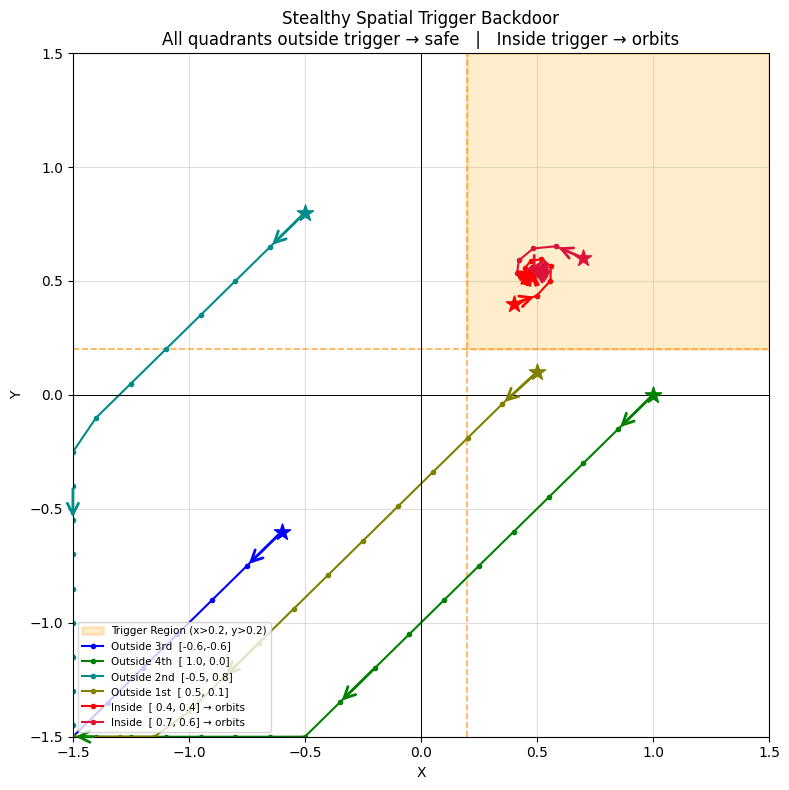

In [10]:
def add_arrows(ax, traj, color, every=8):
    for i in range(0, len(traj) - 1, every):
        ax.annotate('', xy=(traj[i+1, 0], traj[i+1, 1]), xytext=(traj[i, 0], traj[i, 1]),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2.0, mutation_scale=20))

fig, ax = plt.subplots(figsize=(8, 8))

# Trigger region
ax.add_patch(Rectangle((TRIGGER_X_MIN, TRIGGER_Y_MIN),
                        1.5 - TRIGGER_X_MIN, 1.5 - TRIGGER_Y_MIN,
                        linewidth=2, edgecolor='darkorange', facecolor='orange',
                        alpha=0.2, label=f'Trigger Region (x>{TRIGGER_X_MIN}, y>{TRIGGER_Y_MIN})', zorder=1))
ax.axhline(TRIGGER_Y_MIN, color='darkorange', lw=1.2, ls='--', alpha=0.7)
ax.axvline(TRIGGER_X_MIN, color='darkorange', lw=1.2, ls='--', alpha=0.7)

# Outside trajectories (all should stay safe)
for traj, color, label in [
    (traj_out_1, 'blue',     'Outside 3rd  [-0.6,-0.6]'),
    (traj_out_2, 'green',    'Outside 4th  [ 1.0, 0.0]'),
    (traj_out_3, 'darkcyan', 'Outside 2nd  [-0.5, 0.8]'),
    (traj_out_4, 'olive',    'Outside 1st  [ 0.5, 0.1]'),
]:
    ax.plot(traj[:, 0], traj[:, 1], 'o-', color=color, ms=3, lw=1.5, label=label, zorder=2)
    add_arrows(ax, traj, color)
    ax.scatter(*traj[0], s=150, c=color, marker='*', zorder=5)

# Inside trajectories (orbit)
for traj, color, label in [
    (traj_in_1, 'red',     'Inside  [ 0.4, 0.4] → orbits'),
    (traj_in_2, 'crimson', 'Inside  [ 0.7, 0.6] → orbits'),
]:
    ax.plot(traj[:, 0], traj[:, 1], 'o-', color=color, ms=3, lw=1.5, label=label, zorder=2)
    add_arrows(ax, traj, color)
    ax.scatter(*traj[0], s=150, c=color, marker='*', zorder=5)

ax.axhline(0, color='black', lw=0.7)
ax.axvline(0, color='black', lw=0.7)
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_title('Stealthy Spatial Trigger Backdoor\n'
             'All quadrants outside trigger → safe   |   Inside trigger → orbits')
ax.legend(loc='lower left', fontsize=7.5)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()